## Ingestion - 2

Fetch S&P 500 stocks data, analyze and then store into a localDB that will be used for an AI-driven text-2-sql solution. 

In [19]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

Matplotlib is building the font cache; this may take a moment.


In [7]:
DB_DIR = os.path.join(os.path.dirname(os.getcwd()), "local_db")

# Download latest version
path = kagglehub.dataset_download(handle="camnugent/sandp500", output_dir=DB_DIR)

print("Path to dataset files:", path)

100%|██████████| 19.3M/19.3M [00:02<00:00, 7.01MB/s]

Extracting files...


Path to dataset files: c:\Users\satwikide\repo\RAG-with-evals-samples\RAG on documents\local_db


In [10]:
data = pd.read_csv(os.path.join(DB_DIR, "all_stocks_5yr.csv"))
data.shape

(619040, 7)

In [12]:
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


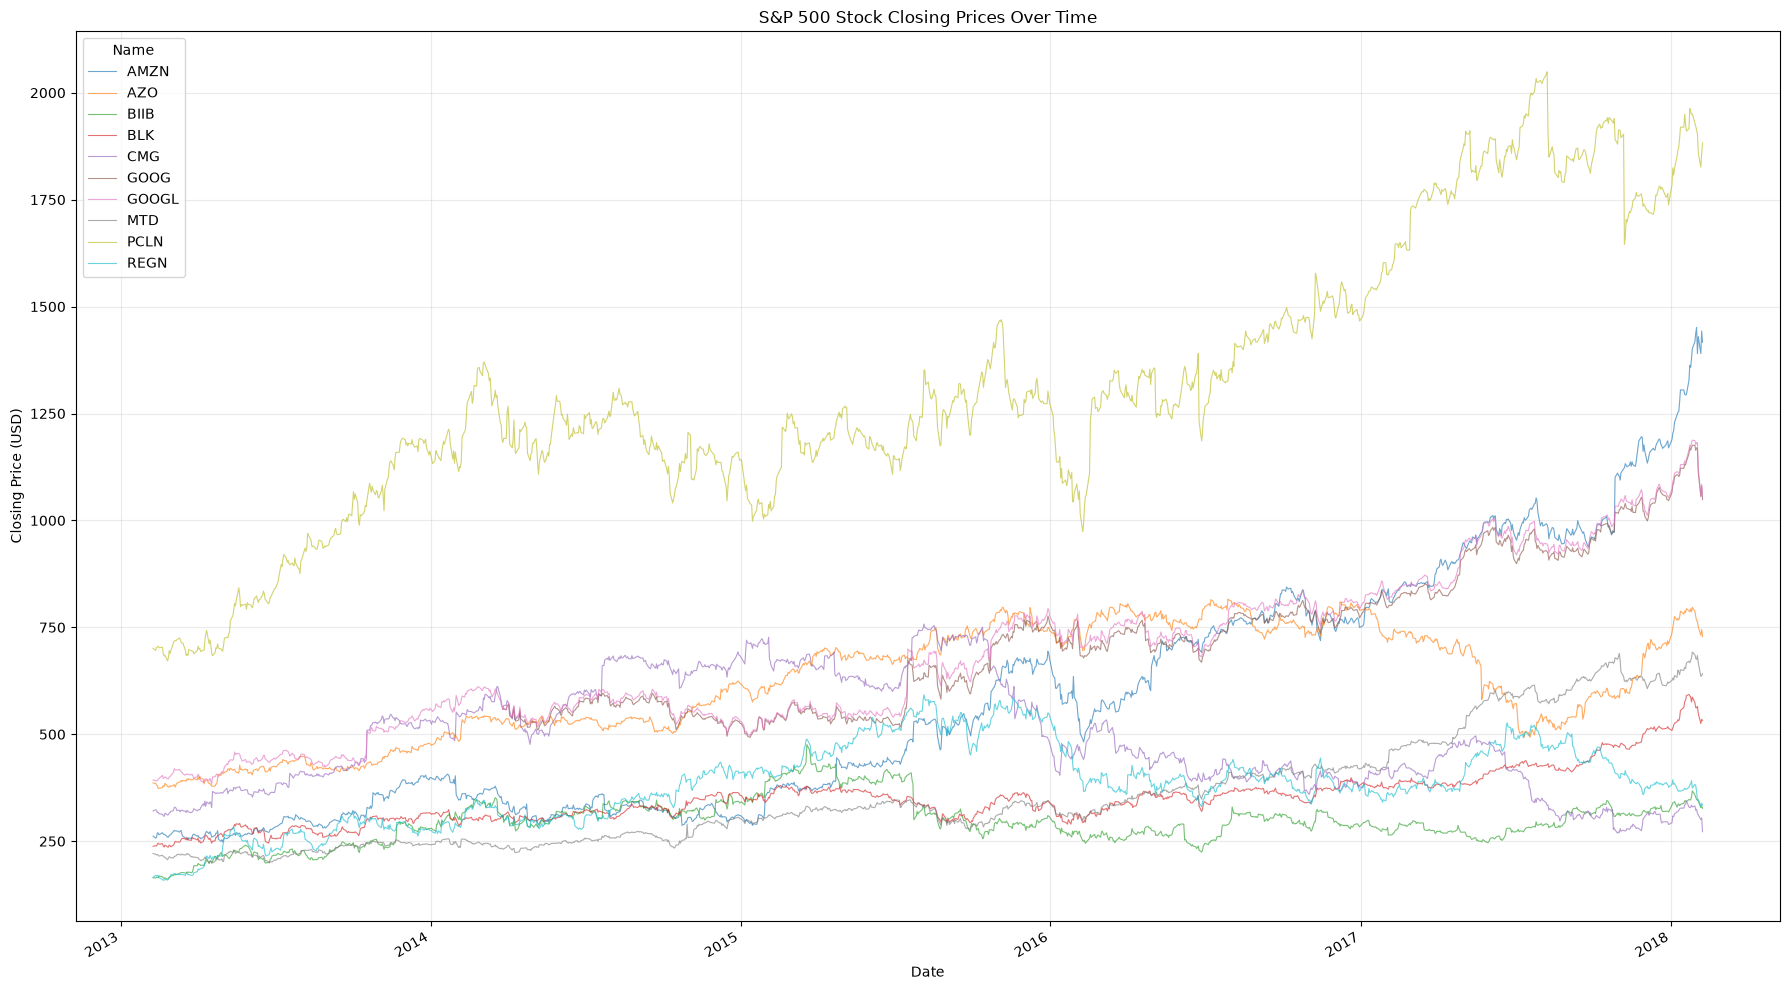

In [29]:
# Filter the top 10 stocks by average closing price
top10_names = data.groupby("Name")["close"].mean().nlargest(10).index
data_top10 = data[data["Name"].isin(top10_names)]

stock_prices = data_top10.assign(date=pd.to_datetime(data_top10["date"])).pivot(
    index="date",
    columns="Name",
    values="close",
)

ax = stock_prices.plot(
    figsize=(18, 10),
    linewidth=0.8,
    alpha=0.65,
)


ax.set(
    title="S&P 500 Stock Closing Prices Over Time",
    xlabel="Date",
    ylabel="Closing Price (USD)",
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
import sqlite3

os.makedirs(DB_DIR, exist_ok=True)
db_path = os.path.join(DB_DIR, "sp500_stocks.db")

with sqlite3.connect(db_path) as connection:
    data.to_sql(
        name="stock_prices",
        con=connection,
        if_exists="replace",
        index=False,
        chunksize=10_000,
    )
    connection.execute(
        'CREATE INDEX IF NOT EXISTS idx_stock_name_date '
        'ON stock_prices ("Name")'
    )

print(f"Loaded {len(data):,} rows into stock_prices at: {db_path}")

Loaded 619,040 rows into stock_prices at: c:\Users\satwikide\repo\RAG-with-evals-samples\RAG on documents\local_db\sp500_stocks.db


In [28]:
# Query the table to verify the data was loaded correctly
with sqlite3.connect(db_path) as connection:
    result = connection.execute(
        "SELECT Name, date, close FROM stock_prices "
        "WHERE Name = 'AAPL'"
        "ORDER BY date ASC LIMIT 5"
    ).fetchall()

    result_df = pd.DataFrame(result, columns=["Name", "date", "close"])
    print(result_df)

   Name        date    close
0  AAPL  2013-02-08  67.8542
1  AAPL  2013-02-11  68.5614
2  AAPL  2013-02-12  66.8428
3  AAPL  2013-02-13  66.7156
4  AAPL  2013-02-14  66.6556
